In [87]:
import pandas as pd

In [88]:
df = pd.read_excel("evcarsdataset.xlsx")

In [89]:
df.head()

,Date,Vehicle_ID,Manufacturer,Model,Driver_Name,Vehicle_Status,Revenue_Generated,Maintenance_Cost,Overspeed_Violation,Present_Battery_%,Expected_Travel_Distance_km,Distance_Travelled_km,Time
0,14-09-2025,EV031,BYD,Atto 3,Arvind Patel,Charging,0.00,0.0,No,17,69,93,12:25
1,23-08-2025,EV085,Hyundai,Kona Electric,Priya Verma,Running,2367.11,0.0,Yes,42,185,241,04:14
2,14-08-2025,EV100,BYD,Atto 3,Kavya Das,Running,106.69,0.0,No,33,125,11,23:05
3,12-10-2025,EV008,Mahindra,XUV400,Sanjay Patel,Running,2459.14,0.0,Yes,33,129,142,18:12
4,08-04-2025,EV036,Hyundai,Kona Electric,Madhavi Rao,Running,655.49,0.0,Yes,39,156,35,08:00


In [90]:
# 1. Running Vehicles Count
running_count = (df['Vehicle_Status'] == 'Running').sum()
print("1. Running Vehicles Count :", running_count)

1. Running Vehicles Count : 6013


In [91]:
#2.garage vehicles count
garage_count = (df['Vehicle_Status'] == 'Garage').sum()
print("2. Garage Vehicles Count :", garage_count)

2. Garage Vehicles Count : 1472


In [92]:
#3.Charging and Running Vehicles
charging_count = (df['Vehicle_Status'] == 'Charging').sum()
print("3. Charging Vehicles :", charging_count)
print("   Running Vehicles :", running_count)


3. Charging Vehicles : 1501
   Running Vehicles : 6013


In [93]:
# 4. Manufacturers
print("4. Manufacturers")
print(df['Manufacturer'].unique())

4. Manufacturers
['BYD' 'Hyundai' 'Mahindra' 'MG' 'Tata']


In [94]:
# 5. Manufacturer Wise Count
print("5. Manufacturer Wise Count")
print(df['Manufacturer'].value_counts())

5. Manufacturer Wise Count
Manufacturer
Hyundai     2283
Mahindra    2124
Tata        2070
BYD         2035
MG          1488
Name: count, dtype: int64


In [95]:
# 6. Month-wise Revenue Generation by Each Car
df['Month'] = pd.to_datetime(df['Date'], format='%d-%m-%Y').dt.month_name()
print("\n6. Month-wise Revenue")
month_revenue = df.groupby(['Vehicle_ID', 'Month'])['Revenue_Generated'].sum()
print(month_revenue)



6. Month-wise Revenue
Vehicle_ID  Month    
EV001       April        12580.33
            August        6705.56
            December      5862.57
            February     12260.14
            January       7574.66
                           ...   
EV100       March        11678.68
            May          12523.25
            November      3357.15
            October      13711.86
            September     6351.58
Name: Revenue_Generated, Length: 1200, dtype: float64


In [96]:
# 7. Month-wise Maintenance
print("\n7. Monthwise Maintenance")
month_maintenance = df.groupby(['Vehicle_ID','Month'])['Maintenance_Cost'].sum()
print(month_maintenance)


7. Monthwise Maintenance
Vehicle_ID  Month    
EV001       April        3515.44
            August          0.00
            December        0.00
            February     3447.65
            January       567.06
                          ...   
EV100       March        4012.44
            May             0.00
            November     4832.69
            October      2129.09
            September    4250.76
Name: Maintenance_Cost, Length: 1200, dtype: float64


In [97]:
# 8. Driver with Maximum Revenue
driver_revenue = df.groupby('Driver_Name')['Revenue_Generated'].sum()
print("\n8. Driver with Maximum Revenue")
print(driver_revenue.idxmax())
print("Revenue :", driver_revenue.max())


8. Driver with Maximum Revenue
Priya Verma
Revenue : 280921.89


In [98]:
# 9. Driver with Minimum Revenue
print("9. Driver with Minimum Revenue")
print(driver_revenue.idxmin())
print("Revenue :", driver_revenue.min())

9. Driver with Minimum Revenue
Gokul Patel
Revenue : 165916.64


In [99]:
df['Overspeed_Violation'] = df['Overspeed_Violation'].map({
    'Yes': 1,
    'No': 0
})

In [100]:
 #10. Driver with Maximum Overspeed Violations
#    along with Overspeed Time
overspeed = df.groupby('Driver_Name')['Overspeed_Violation'].sum()
driver = overspeed.idxmax()
print("\n10. Driver with Maximum Overspeed Violations")
print("Driver :", driver)
print("Violations :", overspeed.max())
print("\nOverspeed Times")
times = df[(df['Driver_Name']==driver) &(df['Overspeed_Violation']>0)][['Date','Time','Overspeed_Violation']]
print(times)


10. Driver with Maximum Overspeed Violations
Driver : Rahul Das
Violations : 171

Overspeed Times
            Date   Time  Overspeed_Violation
187   07-08-2025  21:10                    1
195   11-07-2025  00:26                    1
232   03-06-2025  06:53                    1
271   10-03-2025  06:18                    1
296   14-04-2025  07:55                    1
...          ...    ...                  ...
9723  10-11-2025  09:22                    1
9803  16-03-2025  17:36                    1
9840  22-08-2025  11:57                    1
9852  18-12-2025  16:10                    1
9972  13-10-2025  12:57                    1

[171 rows x 3 columns]


In [101]:
# 11. DDMMYY Column
df['DDMMYY'] = pd.to_datetime(df['Date'], dayfirst=True).dt.strftime('%d%m%y')
print("11. DDMMYY")
print(df[['Date', 'DDMMYY']].head())


11. DDMMYY
         Date  DDMMYY
0  14-09-2025  140925
1  23-08-2025  230825
2  14-08-2025  140825
3  12-10-2025  121025
4  08-04-2025  080425


In [102]:
# 12. Present Battery Percentage
print("12. Present Battery Percentage")
print(df[['Vehicle_ID','Present_Battery_%']])


12. Present Battery Percentage
     Vehicle_ID  Present_Battery_%
0         EV031                 17
1         EV085                 42
2         EV100                 33
3         EV008                 33
4         EV036                 39
...         ...                ...
9995      EV043                 29
9996      EV014                 13
9997      EV077                 34
9998      EV035                 36
9999      EV083                 31

[10000 rows x 2 columns]


In [103]:
# 13. Expected Travelling Distance
print("13. Expected Travelling Distance")
print(df[['Vehicle_ID','Expected_Travel_Distance_km']])

13. Expected Travelling Distance
     Vehicle_ID  Expected_Travel_Distance_km
0         EV031                           69
1         EV085                          185
2         EV100                          125
3         EV008                          129
4         EV036                          156
...         ...                          ...
9995      EV043                          113
9996      EV014                           51
9997      EV077                          136
9998      EV035                          161
9999      EV083                          130

[10000 rows x 2 columns]


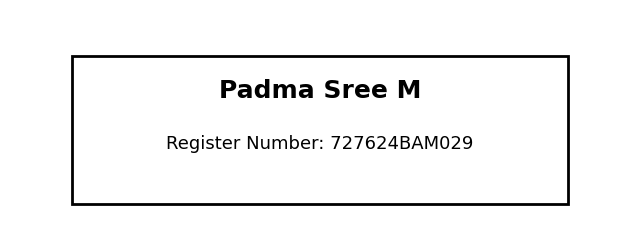

In [104]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8, 3))
ax.set_xlim(0, 10)
ax.set_ylim(0, 5)
ax.axis('off')
box = plt.Rectangle((1, 0.8), 8, 3.2, fill=False, linewidth=2)
ax.add_patch(box)
ax.text(5, 3.1, "Padma Sree M",
        fontsize=18, fontweight='bold', ha='center')
ax.text(5, 2.0, "Register Number: 727624BAM029",
       fontsize=13, ha='center')

plt.show()